# Student Performance & Traffic Volume Statistical Analysis
### Exploratory Data Analysis & Inferential Statistics

This notebook contains **Phase 1** of the Student Performance and Traffic Statistical Analysis project. It carries out exploratory data analysis (EDA) and computes statistical measures on synthetic academic and traffic observations.

### Objectives:
1. **Load and inspect** dataset characteristics (dimensions, data types, missing values).
2. **Compute descriptive statistics** including central tendency, dispersion, and skewness.
3. **Analyze associations** through covariance and correlation matrices visualized via Seaborn heatmaps.
4. **Perform statistical inference** by constructing 95% Confidence Intervals for population means.
5. **Visualize univariate distributions** using Histograms and Kernel Density Estimates (KDE).
6. **Explore detailed multivariate visualizations** (box plots, violin plots, regression plots, pair plots, and calendar heatmaps) using a consistent color palette.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setting plotting theme and consistent palette
sns.set_theme(style="whitegrid")
sns.set_palette("viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10

print("Libraries successfully imported. Consistent Viridis palette configured.")

Libraries successfully imported. Consistent Viridis palette configured.


## 1. Loading and Inspecting the Datasets
We load both the student performance and traffic volume CSV files. 

*(Note: Adjust the column names in the mapping dictionary below if you download real datasets with different schemas.)*

In [2]:
# =========================================================================
# ADJUST COLUMN NAMES HERE IF YOU LOAD REAL DATASETS
# Make sure these lists contain numerical column names matching your local CSVs
# =========================================================================
STUDENT_NUMERIC_COLS = ['age', 'study_time', 'failures', 'absences', 'G1', 'G2', 'G3']
TRAFFIC_NUMERIC_COLS = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'hour']

# File paths
student_csv_path = os.path.join("..", "data", "student_performance.csv")
traffic_csv_path = os.path.join("..", "data", "traffic_volume.csv")

try:
    student_df = pd.read_csv(student_csv_path)
    traffic_df = pd.read_csv(traffic_csv_path)
    print("Both datasets loaded successfully.")
except Exception as e:
    print(f"Error loading datasets: {e}")
    print("Please verify that the CSV files are placed in the /data directory.")

Both datasets loaded successfully.


In [3]:
# Inspect Student Performance structure
print("=== STUDENT PERFORMANCE DATASET ===")
print(f"Shape: {student_df.shape}")
print("\n--- Data Types ---")
print(student_df.dtypes)
print("\n--- Missing Values Count ---")
print(student_df.isnull().sum())
student_df.head()

=== STUDENT PERFORMANCE DATASET ===
Shape: (120, 10)

--- Data Types ---
age                  int64
study_time           int64
failures             int64
absences             int64
sex                 object
schoolsup           object
parent_education    object
G1                   int64
G2                   int64
G3                   int64
dtype: object

--- Missing Values Count ---
age                 0
study_time          0
failures            0
absences            0
sex                 0
schoolsup           0
parent_education    0
G1                  0
G2                  0
G3                  0
dtype: int64


,age,study_time,failures,absences,sex,schoolsup,parent_education,G1,G2,G3
0,18,4,0,8,F,yes,primary,18,19,20
1,16,3,0,12,M,no,primary,13,4,7
2,21,2,0,5,M,yes,higher,19,16,15
3,20,2,0,3,M,no,higher,12,15,17
4,18,3,1,7,F,no,primary,4,13,12


In [4]:
# Inspect Traffic Volume structure
print("=== TRAFFIC VOLUME DATASET ===")
print(f"Shape: {traffic_df.shape}")
print("\n--- Data Types ---")
print(traffic_df.dtypes)
print("\n--- Missing Values Count ---")
print(traffic_df.isnull().sum())
traffic_df.head()

=== TRAFFIC VOLUME DATASET ===
Shape: (200, 9)

--- Data Types ---
date_time          object
temp              float64
rain_1h           float64
snow_1h           float64
clouds_all          int64
weather_main       object
holiday            object
hour                int64
traffic_volume      int64
dtype: object

--- Missing Values Count ---
date_time           0
temp                0
rain_1h             0
snow_1h             0
clouds_all          0
weather_main        0
holiday           186
hour                0
traffic_volume      0
dtype: int64


,date_time,temp,rain_1h,snow_1h,clouds_all,weather_main,holiday,hour,traffic_volume
0,2026-06-01 00:00:00,299.06,0.5,0.0,11,Clouds,NaN,0,250
1,2026-06-01 01:00:00,302.92,0.0,0.0,96,Clear,NaN,1,199
2,2026-06-01 02:00:00,283.34,0.0,0.0,94,Clouds,NaN,2,453
3,2026-06-01 03:00:00,285.04,0.0,0.0,53,Clear,NaN,3,220
4,2026-06-01 04:00:00,294.64,0.5,0.0,92,Rain,NaN,4,50


## 2. Descriptive Statistics
We calculate the central tendencies (mean, median), measures of dispersion (standard deviation, range, percentiles), and shapes of distributions (skewness).

In [5]:
# 2.1 Student Performance Descriptive Statistics
student_desc = student_df[STUDENT_NUMERIC_COLS].describe().T

# Calculate skewness
student_skew = student_df[STUDENT_NUMERIC_COLS].apply(lambda x: stats.skew(x.dropna()))
student_desc['skewness'] = student_skew

print("=== Descriptive Statistics: Student Performance ===")
display(student_desc)

=== Descriptive Statistics: Student Performance ===


,count,mean,std,min,25%,50%,75%,max,skewness
age,120.0,18.091667,1.860676,15.0,17.0,18.0,19.00,21.0,-0.118407
study_time,120.0,2.508333,1.084620,1.0,2.0,2.5,3.00,4.0,-0.001652
failures,120.0,0.333333,0.714006,0.0,0.0,0.0,0.00,3.0,2.060691
absences,120.0,8.433333,6.847355,0.0,3.0,7.0,12.00,33.0,1.339120
G1,120.0,11.408333,4.772991,4.0,7.0,11.0,15.25,19.0,0.122608
G2,120.0,11.416667,4.646465,4.0,7.0,12.0,15.00,19.0,-0.099106
G3,120.0,11.808333,3.555788,5.0,9.0,11.0,15.00,20.0,0.232557


In [6]:
# 2.2 Traffic Volume Descriptive Statistics
traffic_desc = traffic_df[TRAFFIC_NUMERIC_COLS].describe().T

# Calculate skewness
traffic_skew = traffic_df[TRAFFIC_NUMERIC_COLS].apply(lambda x: stats.skew(x.dropna()))
traffic_desc['skewness'] = traffic_skew

print("=== Descriptive Statistics: Traffic Volume ===")
display(traffic_desc)

=== Descriptive Statistics: Traffic Volume ===


,count,mean,std,min,25%,50%,75%,max,skewness
temp,200.0,289.9127,7.738604,267.96,284.455,289.675,295.3525,306.04,-0.114091
rain_1h,200.0,0.0265,0.104894,0.00,0.000,0.000,0.0000,0.50,4.169472
snow_1h,200.0,0.0080,0.074591,0.00,0.000,0.000,0.0000,1.00,12.106330
clouds_all,200.0,50.0150,29.648778,0.00,25.000,48.500,76.0000,100.00,0.025675
traffic_volume,200.0,2107.1950,1447.167060,50.00,613.500,2325.000,2659.0000,4753.00,0.270506
hour,200.0,11.1800,6.993723,0.00,5.000,11.000,17.0000,23.00,0.062541


## 3. Covariance & Correlation Heatmaps

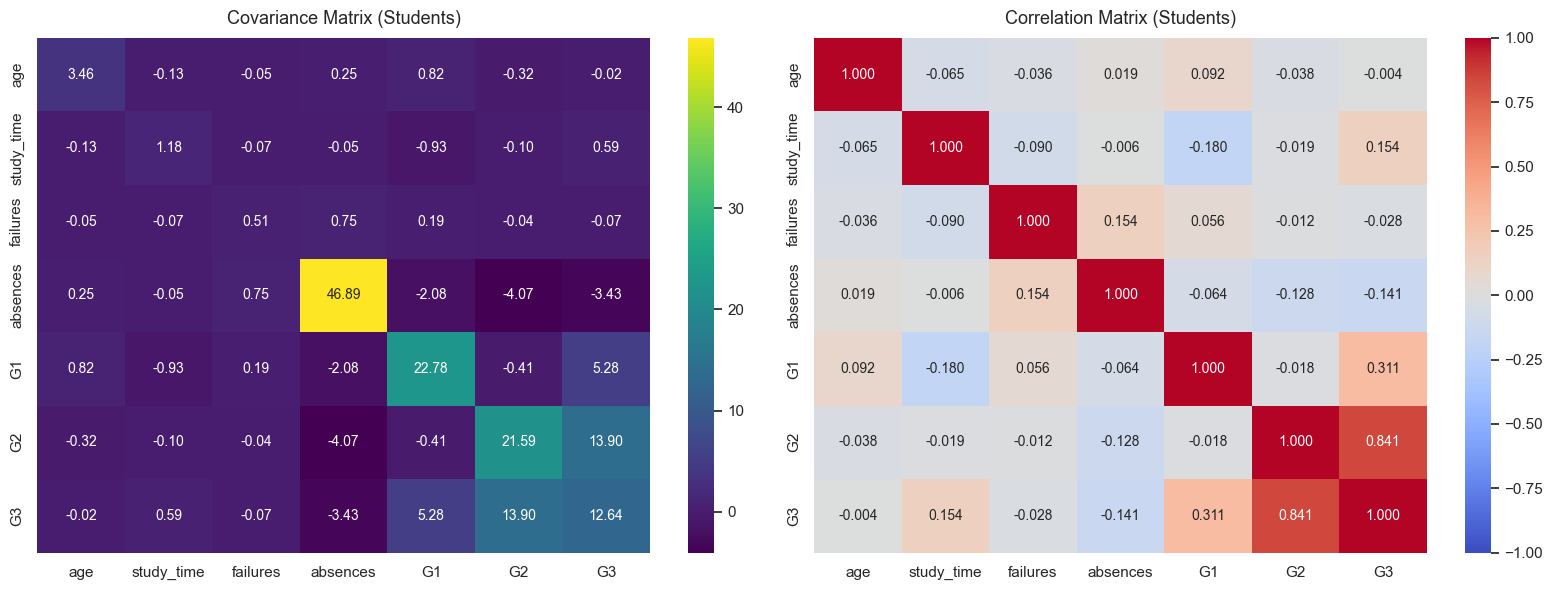

In [7]:
# 3.1 Student Performance Matrices
student_cov = student_df[STUDENT_NUMERIC_COLS].cov()
student_corr = student_df[STUDENT_NUMERIC_COLS].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(student_cov, annot=True, cmap="viridis", fmt=".2f", ax=axes[0])
axes[0].set_title("Covariance Matrix (Students)", fontsize=13, pad=10)

sns.heatmap(student_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f", ax=axes[1])
axes[1].set_title("Correlation Matrix (Students)", fontsize=13, pad=10)

plt.tight_layout()
plt.show()

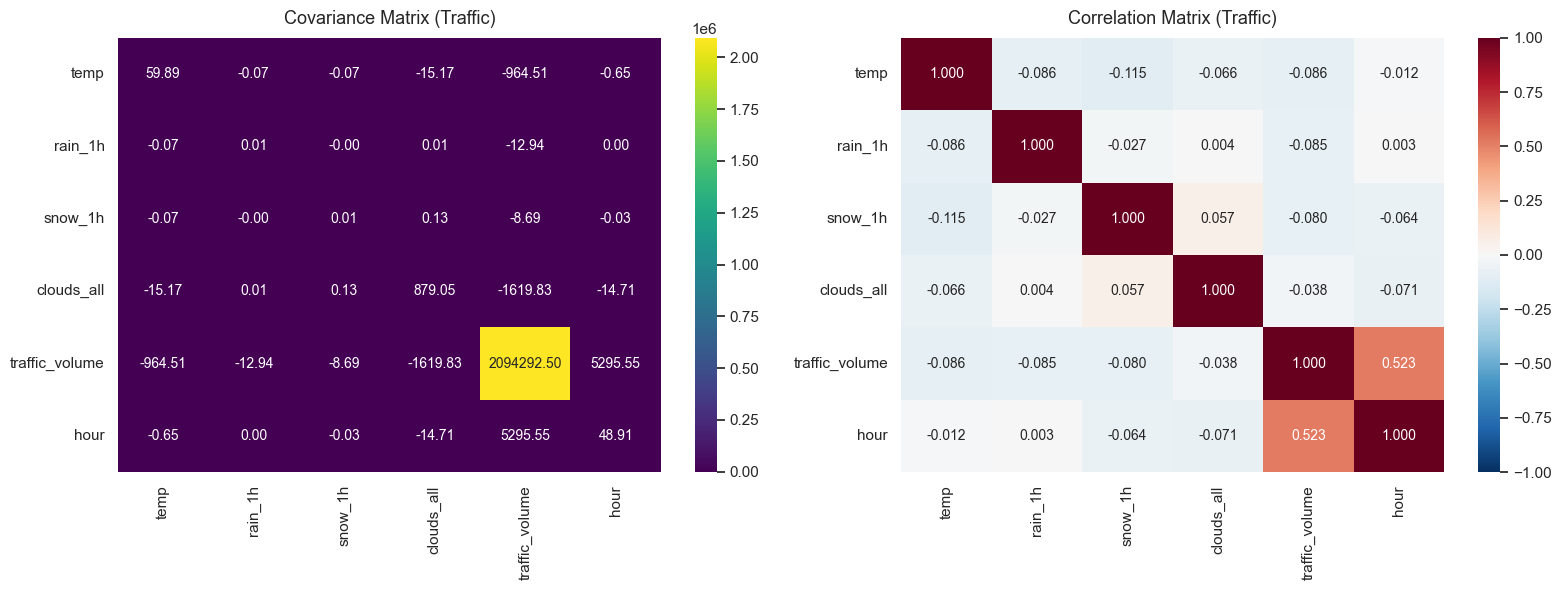

In [8]:
# 3.2 Traffic Volume Matrices
traffic_cov = traffic_df[TRAFFIC_NUMERIC_COLS].cov()
traffic_corr = traffic_df[TRAFFIC_NUMERIC_COLS].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(traffic_cov, annot=True, cmap="viridis", fmt=".2f", ax=axes[0])
axes[0].set_title("Covariance Matrix (Traffic)", fontsize=13, pad=10)

sns.heatmap(traffic_corr, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, fmt=".3f", ax=axes[1])
axes[1].set_title("Correlation Matrix (Traffic)", fontsize=13, pad=10)

plt.tight_layout()
plt.show()

## 4. Confidence Intervals
We calculate 2 key confidence intervals per dataset using the Student's t-distribution.

In [9]:
def print_confidence_interval(series, name, unit=""):
    n = len(series)
    mean = np.mean(series)
    sem = stats.sem(series)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
    
    print(f"--- 95% Confidence Interval for {name} ---")
    print(f"Sample Size (n): {n}")
    print(f"Sample Mean: {mean:.3f} {unit}")
    print(f"Confidence Interval Range: ({ci[0]:.3f} {unit}, {ci[1]:.3f} {unit})")
    print(f"Interpretation: If we repeated sampling many times, 95% of the calculated intervals")
    print(f"                would contain the true population mean of {name}.\n")

# 4.1 Student CIs
print_confidence_interval(student_df['study_time'], "Student Weekly Study Time Grade Scale", "units")
print_confidence_interval(student_df['G3'], "Student Final Grade (G3)", "points")

# 4.2 Traffic CIs
print_confidence_interval(traffic_df['temp'], "Ambient Temperature", "Kelvin")
print_confidence_interval(traffic_df['traffic_volume'], "Hourly Traffic Volume", "vehicles")

--- 95% Confidence Interval for Student Weekly Study Time Grade Scale ---
Sample Size (n): 120
Sample Mean: 2.508 units
Confidence Interval Range: (2.312 units, 2.704 units)
Interpretation: If we repeated sampling many times, 95% of the calculated intervals
                would contain the true population mean of Student Weekly Study Time Grade Scale.

--- 95% Confidence Interval for Student Final Grade (G3) ---
Sample Size (n): 120
Sample Mean: 11.808 points
Confidence Interval Range: (11.166 points, 12.451 points)
Interpretation: If we repeated sampling many times, 95% of the calculated intervals
                would contain the true population mean of Student Final Grade (G3).

--- 95% Confidence Interval for Ambient Temperature ---
Sample Size (n): 200
Sample Mean: 289.913 Kelvin
Confidence Interval Range: (288.834 Kelvin, 290.992 Kelvin)
Interpretation: If we repeated sampling many times, 95% of the calculated intervals
                would contain the true population mean of A

## 5. Univariate Distribution Visualizations

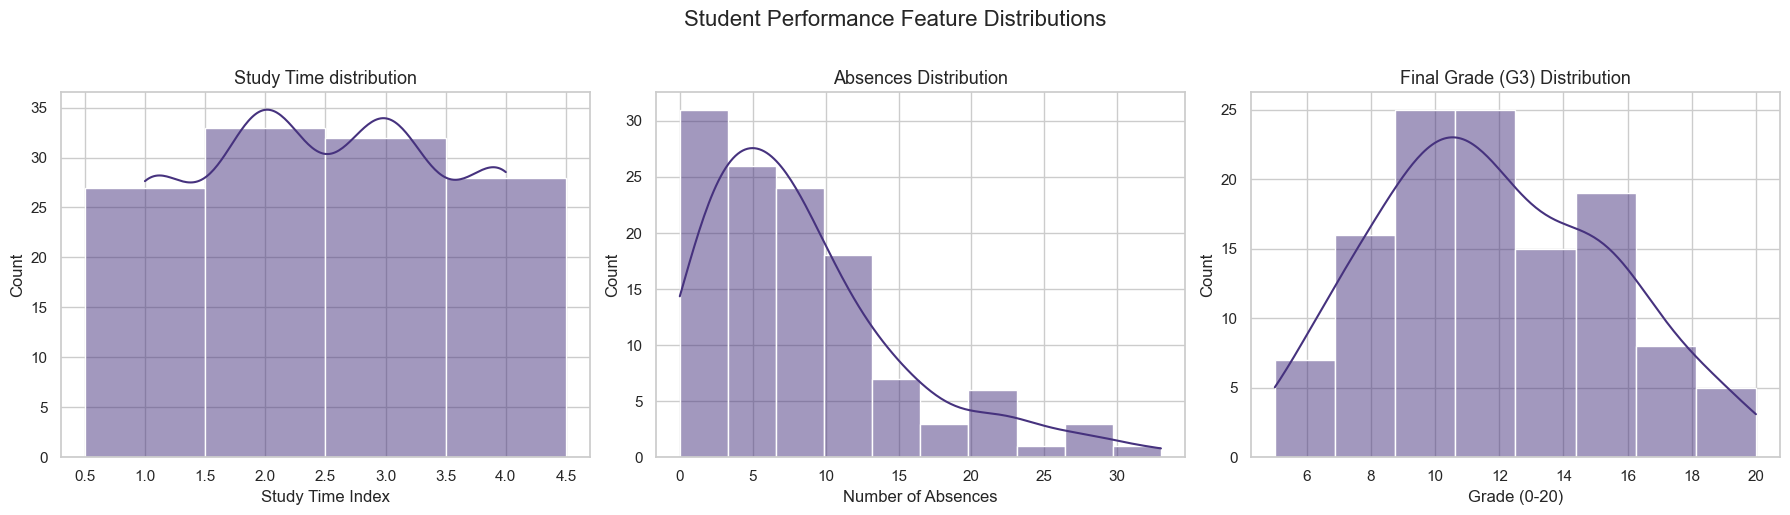

In [10]:
# 5.1 Student Performance distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(student_df['study_time'], kde=True, discrete=True, ax=axes[0])
axes[0].set_title("Study Time distribution", fontsize=13)
axes[0].set_xlabel("Study Time Index")

sns.histplot(student_df['absences'], kde=True, ax=axes[1])
axes[1].set_title("Absences Distribution", fontsize=13)
axes[1].set_xlabel("Number of Absences")

sns.histplot(student_df['G3'], kde=True, ax=axes[2])
axes[2].set_title("Final Grade (G3) Distribution", fontsize=13)
axes[2].set_xlabel("Grade (0-20)")

plt.suptitle("Student Performance Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

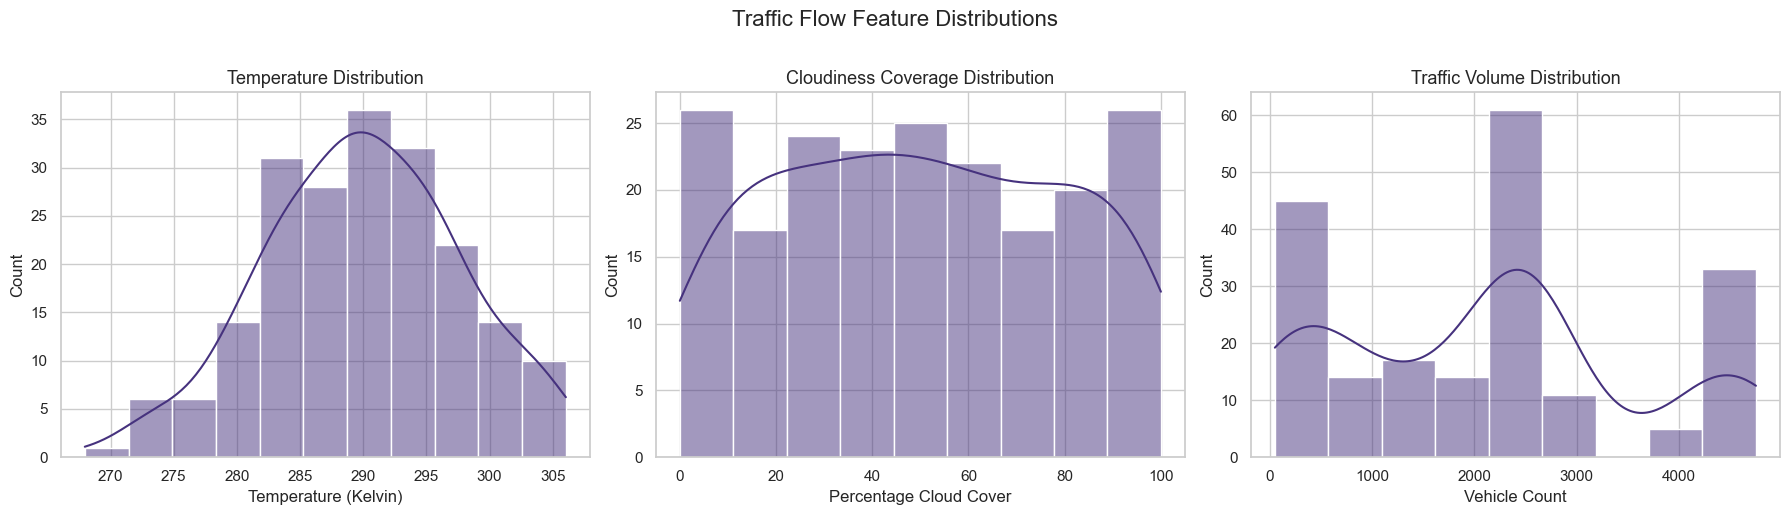

In [11]:
# 5.2 Traffic Volume distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(traffic_df['temp'], kde=True, ax=axes[0])
axes[0].set_title("Temperature Distribution", fontsize=13)
axes[0].set_xlabel("Temperature (Kelvin)")

sns.histplot(traffic_df['clouds_all'], kde=True, ax=axes[1])
axes[1].set_title("Cloudiness Coverage Distribution", fontsize=13)
axes[1].set_xlabel("Percentage Cloud Cover")

sns.histplot(traffic_df['traffic_volume'], kde=True, ax=axes[2])
axes[2].set_title("Traffic Volume Distribution", fontsize=13)
axes[2].set_xlabel("Vehicle Count")

plt.suptitle("Traffic Flow Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Student Performance: Advanced Visualizations

### Question: How does the distribution of final grades vary across different weekly study time groups?

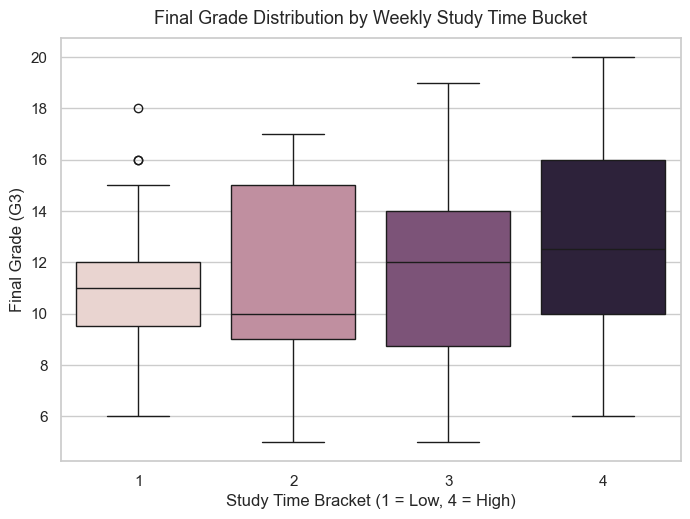

In [12]:
# 1. Box plot: final grade grouped by study_time buckets
plt.figure(figsize=(8, 5.5))
sns.boxplot(data=student_df, x='study_time', y='G3', hue='study_time', legend=False)
plt.title("Final Grade Distribution by Weekly Study Time Bucket", fontsize=13, pad=10)
plt.xlabel("Study Time Bracket (1 = Low, 4 = High)")
plt.ylabel("Final Grade (G3)")
plt.show()

[Insight: describe what the box plot reveals about grade spread across study groups]

### Question: How does school support impact the distribution and density of final grades?

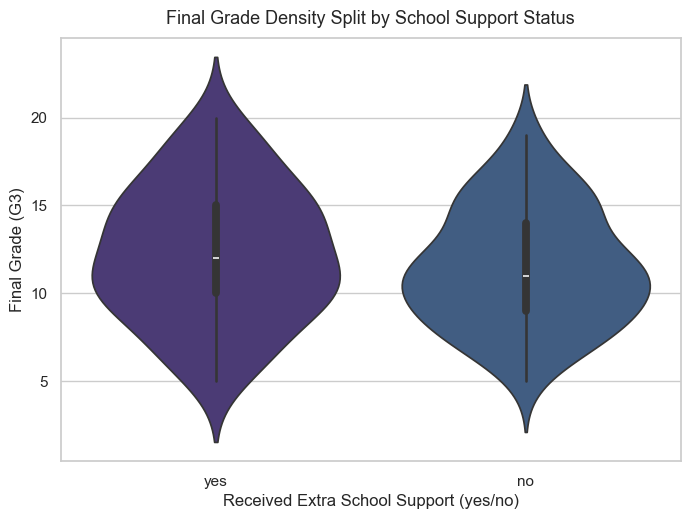

In [13]:
# 2. Violin plot: final grade distribution split by school support status
plt.figure(figsize=(8, 5.5))
sns.violinplot(data=student_df, x='schoolsup', y='G3', hue='schoolsup', legend=False)
plt.title("Final Grade Density Split by School Support Status", fontsize=13, pad=10)
plt.xlabel("Received Extra School Support (yes/no)")
plt.ylabel("Final Grade (G3)")
plt.show()

[Insight: describe what the violin plot reveals about final grades for students with vs without school support]

### Question: Is there a differences in average final grades based on parental education levels?

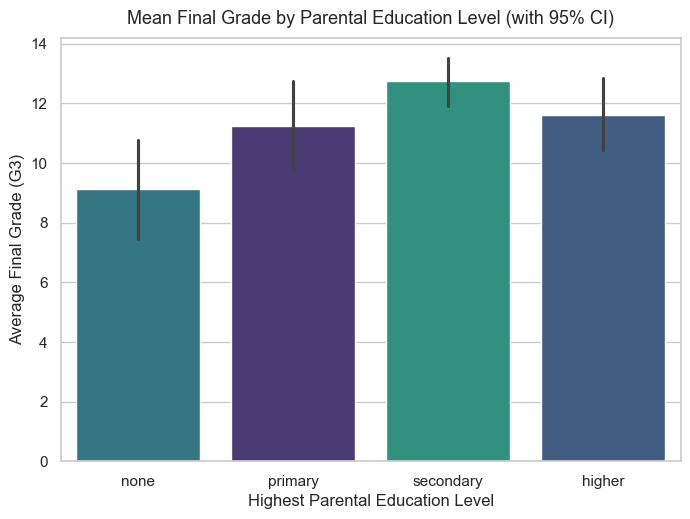

In [14]:
# 3. Bar chart: average final grade by parental education with 95% Confidence Interval error bars
plt.figure(figsize=(8, 5.5))
sns.barplot(data=student_df, x='parent_education', y='G3', errorbar=('ci', 95),
            order=['none', 'primary', 'secondary', 'higher'], hue='parent_education', legend=False)
plt.title("Mean Final Grade by Parental Education Level (with 95% CI)", fontsize=13, pad=10)
plt.xlabel("Highest Parental Education Level")
plt.ylabel("Average Final Grade (G3)")
plt.show()

[Insight: describe what the bar chart reveals about average final grades based on the group comparisons and their error intervals]

### Question: What is the linear relationship between period 2 grades (G2) and final grades (G3)?

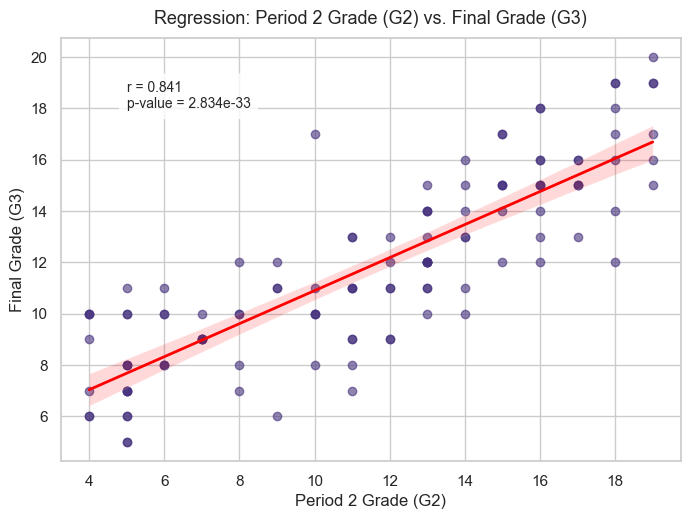

In [15]:
# 4. Scatter plot with regression line: Strongest correlated pair (G2 vs G3)
plt.figure(figsize=(8, 5.5))
r_val, p_val = stats.pearsonr(student_df['G2'], student_df['G3'])
sns.regplot(data=student_df, x='G2', y='G3', scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'linewidth':2})
plt.title("Regression: Period 2 Grade (G2) vs. Final Grade (G3)", fontsize=13, pad=10)
plt.xlabel("Period 2 Grade (G2)")
plt.ylabel("Final Grade (G3)")
# Annotate correlation coefficient and p-value
plt.text(5, 18, f"r = {r_val:.3f}\np-value = {p_val:.3e}", bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
plt.show()

[Insight: describe the strength and direction of the linear relationship, and the significance indicated by the p-value]

### Question: How are the pairwise relationships among key numeric features structured when students are categorized by pass/fail status?

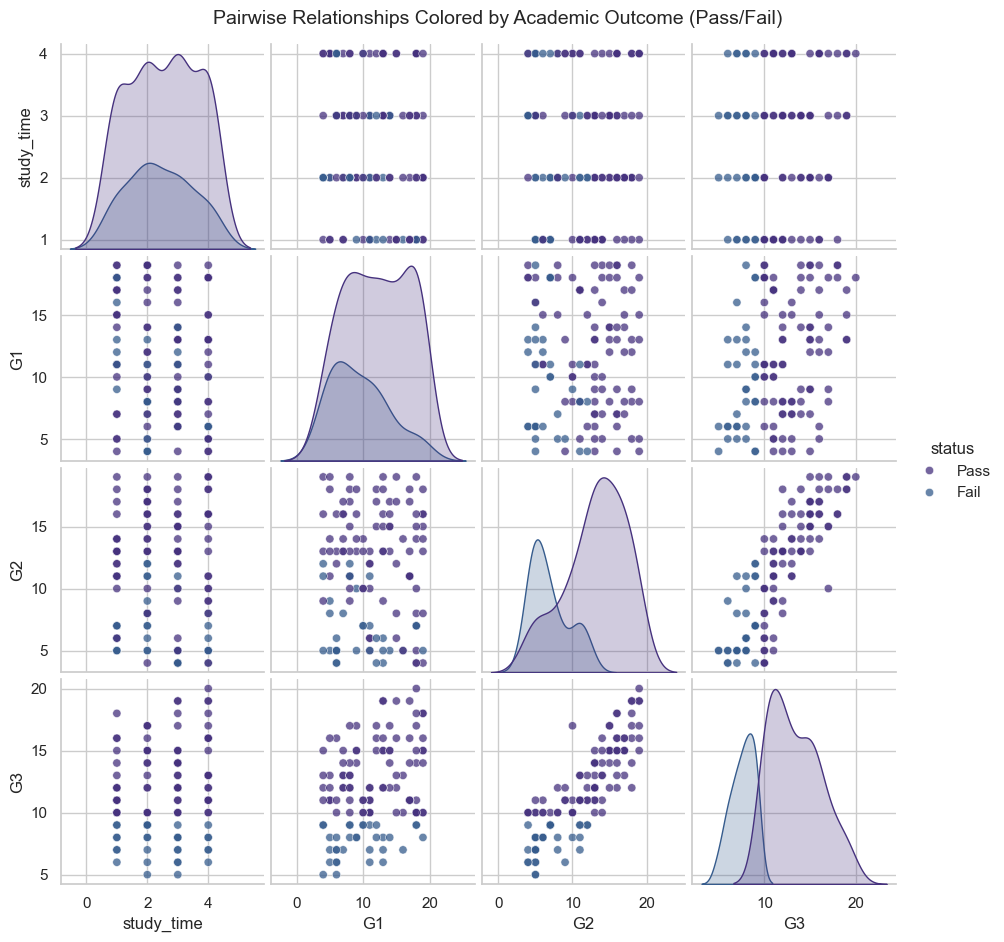

In [16]:
# 5. Pair plot with hue: Color points by pass/fail status (Pass = G3 >= 10)
student_df['status'] = np.where(student_df['G3'] >= 10, 'Pass', 'Fail')
highly_correlated_student = ['study_time', 'G1', 'G2', 'G3', 'status']
sns.pairplot(student_df[highly_correlated_student], hue='status', height=2.3, diag_kind="kde", 
             plot_kws={'alpha': 0.75})
plt.suptitle("Pairwise Relationships Colored by Academic Outcome (Pass/Fail)", fontsize=14, y=1.02)
plt.show()

[Insight: describe how the bivariate scatter clusters differ between passing and failing students across variables]

## 7. Traffic Volume: Advanced Visualizations

### Question: How does the distribution of hourly traffic volume change across different weather conditions?

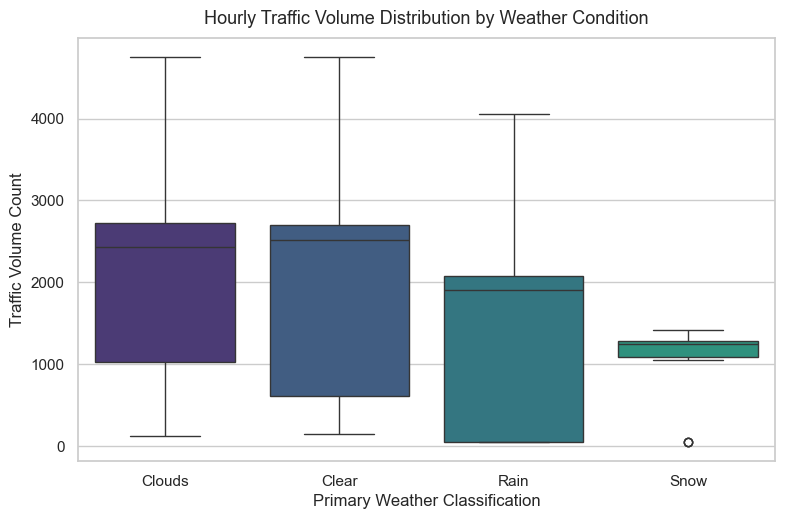

In [17]:
# 6. Box plot: Traffic volume grouped by weather condition
plt.figure(figsize=(9, 5.5))
sns.boxplot(data=traffic_df, x='weather_main', y='traffic_volume', hue='weather_main', legend=False)
plt.title("Hourly Traffic Volume Distribution by Weather Condition", fontsize=13, pad=10)
plt.xlabel("Primary Weather Classification")
plt.ylabel("Traffic Volume Count")
plt.show()

[Insight: describe the variation in traffic volume median and dispersion across different weather conditions]

### Question: Does average traffic volume decrease significantly on holidays compared to regular non-holiday hours?

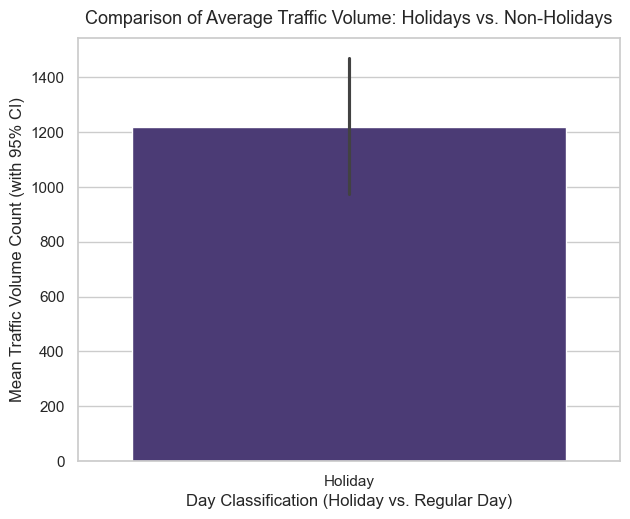

In [18]:
# 7. Bar chart: traffic volume comparing holiday vs non-holiday with error bars (95% CI)
plt.figure(figsize=(7, 5.5))
sns.barplot(data=traffic_df, x='holiday', y='traffic_volume', errorbar=('ci', 95), hue='holiday', legend=False)
plt.title("Comparison of Average Traffic Volume: Holidays vs. Non-Holidays", fontsize=13, pad=10)
plt.xlabel("Day Classification (Holiday vs. Regular Day)")
plt.ylabel("Mean Traffic Volume Count (with 95% CI)")
plt.show()

[Insight: describe what the bar chart reveals about average traffic volume on holidays vs non-holidays and their overlap]

### Question: What temporal rush hour patterns are revealed when traffic volume is structured by hour of day and day of week?

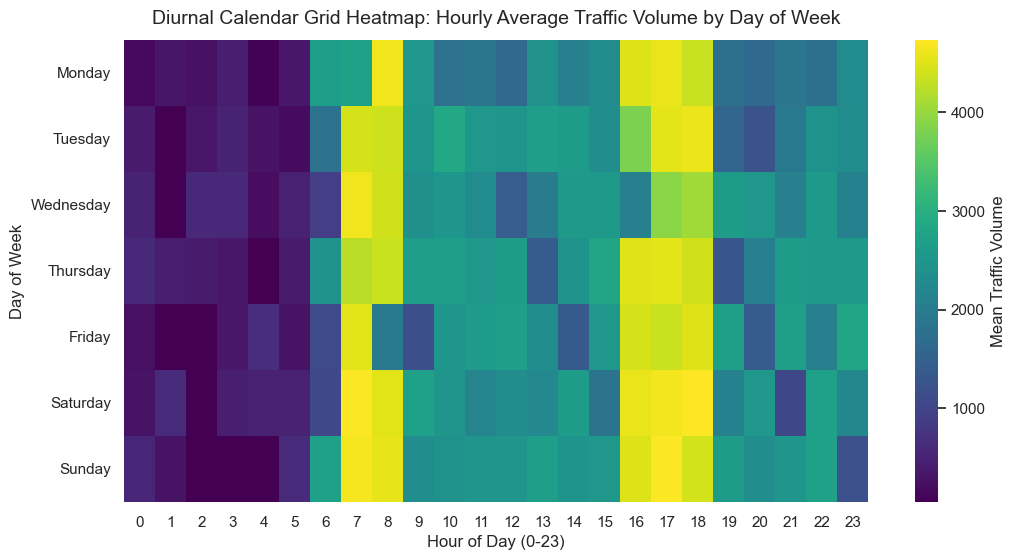

In [19]:
# 8. Calendar-style heatmap: traffic volume by hour-of-day vs day-of-week
traffic_df['day_name'] = pd.to_datetime(traffic_df['date_time']).dt.day_name()
# Create pivot table of mean volume
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traffic_pivot = traffic_df.pivot_table(values='traffic_volume', index='day_name', columns='hour', aggfunc='mean')
traffic_pivot = traffic_pivot.reindex(day_order)

plt.figure(figsize=(12, 6))
sns.heatmap(traffic_pivot, cmap='viridis', cbar_kws={'label': 'Mean Traffic Volume'})
plt.title("Diurnal Calendar Grid Heatmap: Hourly Average Traffic Volume by Day of Week", fontsize=14, pad=12)
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Day of Week")
plt.show()

[Insight: describe the peak volume hours and days visible in the temporal heatmap grid]